#  Обратное распространение ошибки

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann 
* http://cs231n.stanford.edu/handouts/linear-backprop.pdf
* https://www.adityaagrawal.net/blog/deep_learning/bprop_fc
* https://en.wikipedia.org/wiki/Stochastic_gradient_descent

In [11]:
from torchtyping import TensorType, patch_typeguard
from typeguard import typechecked
import torch as th
from sklearn.datasets import make_regression
from torch.utils.data import DataLoader, TensorDataset

Scalar = TensorType[()]
patch_typeguard()

## Задачи для совместного разбора

1\. Реализуйте обратное распространение ошибки для модели нейрона с квадратичной функцией потерь при условии, что на вход нейрону поступает вектор `inputs`. Проверьте корректность вычисления градиентов, воспользовавшись возможностями по автоматическому дифференцированию `torch`. 

2\. Настройте модель нейрона, используя метод стохастического градиентного спуска и собственную реализацию обратного распространения ошибки.

In [3]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt

X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5, random_state=42)
X = th.FloatTensor(X)
y = th.FloatTensor(y)

In [4]:
y_preds = neuron.forward(X)
(y_preds - y).pow(2).mean()

NameError: name 'neuron' is not defined

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Реализуйте обратное распространение ошибки для модели нейрона с функцией потерь MSE при условии, что на вход нейрону поступает пакет (двумерный тензор) `inputs`. Проверьте корректность вычисления градиентов, воспользовавшись возможностями по автоматическому дифференцированию `torch`. 

$$\mathbf{X} = \begin{bmatrix}
x_{10} & x_{11} & \ldots & x_{1m} \\
x_{20} & x_{21} & \ldots & x_{2m} \\
\vdots & \vdots & \ddots & \vdots \\
x_{k0} & x_{k1} & \ldots & x_{km} \\
\end{bmatrix}
\mathbf{Y} = \begin{bmatrix}
y_{1} \\
y_{2} \\
\vdots \\
y_{k} \\
\end{bmatrix}
\mathbf{W} = \begin{bmatrix}
w_{0} \\
w_{1} \\
\vdots \\
w_{m} \\
\end{bmatrix}$$

$$\hat{\mathbf{Y}} = \mathbf{X}\times \mathbf{W}$$

$$L = \frac{1}{k}\sum_{k}{(\hat{y_k}-y_k)^2}$$

$$\nabla_{\hat{\mathbf{Y}}} L=\begin{bmatrix}
\frac{\partial L}{\partial \hat{y_1}} \\
\frac{\partial L}{\partial \hat{y_2}} \\
\vdots \\
\frac{\partial L}{\partial \hat{y_k}} \\
\end{bmatrix} = \frac{2}{k}\begin{bmatrix}
\hat{y_1} - y_1 \\
\hat{y_2} - y_2 \\
\vdots \\
\hat{y_k} - y_k \\
\end{bmatrix}$$

$$\boldsymbol{\nabla_{\mathbf{W}} L = \mathbf{X}^T\nabla_{\hat{\mathbf{Y}}} L}$$

- [ ] Проверено на семинаре

In [5]:
import torch as th

class NeuronBatch:
    def __init__(self, n_features: int, seed: int | None = None, grad: bool = False):
        if seed is not None:
            th.manual_seed(seed)
        self.weights = th.randn(n_features + 1, 1, requires_grad=grad)

    def add_ones_col(self, inputs):
        ones = th.ones((inputs.shape[0], 1), dtype=inputs.dtype)
        return th.cat((ones, inputs), dim=1)
        
    def forward(self, inputs):
        return self.add_ones_col(inputs) @ self.weights

    def backward(self, inputs, dnext) -> None:
        self.dweights = self.add_ones_col(inputs).T @ dnext


class MSELoss:
    def forward(self, y_pred, y_true):
        return ((y_pred - y_true) ** 2).mean()

    def backward(self, y_pred, y_true) -> None:
        self.dinput = 2 * (y_pred - y_true) / y_pred.shape[0]

In [8]:
inputs = th.randn(5, 3)
y_true = th.randn(5, 1)

model = NeuronBatch(3, seed=123, grad=False)
y_pred = model.forward(inputs)

criterion = MSELoss()
loss = criterion.forward(y_pred, y_true)
criterion.backward(y_pred, y_true)
model.backward(inputs, criterion.dinput)

print(model.dweights)

model2 = NeuronBatch(3, seed=123, grad=True)
y_pred2 = model2.forward(inputs)
loss2 = criterion.forward(y_pred2, y_true)
loss2.backward()

print(model2.weights.grad)
print(th.allclose(model.dweights, model2.weights.grad))

tensor([[-0.0609],
        [-0.2162],
        [-0.2168],
        [-0.4810]])
tensor([[-0.0609],
        [-0.2162],
        [-0.2168],
        [-0.4810]])
True


<p class="task" id="2"></p>

2\. Настройте модель нейрона, используя метод мини-пакетного градиентного спуска. 

Используйте обратное распространение ошибки, реализованное самостоятельно. Выведите на экран полученные и правильные коэффициенты модели.

- [ ] Проверено на семинаре

In [13]:
class NeuronBatch:
    def __init__(self, n_features: int, seed: int | None = None, grad: bool = False):
        if seed is not None:
            th.manual_seed(seed)
        self.weights = th.randn(n_features + 1, 1, requires_grad=grad)

    def add_ones_col(self, inputs):
        ones = th.ones((inputs.shape[0], 1), dtype=inputs.dtype)
        return th.cat((ones, inputs), dim=1)

    def forward(self, inputs):
        return self.add_ones_col(inputs) @ self.weights

    def backward(self, inputs, dnext):
        x_bias = self.add_ones_col(inputs)
        self.dweights = x_bias.T @ dnext


class MSELoss:
    def forward(self, y_pred, y_true):
        return ((y_pred - y_true) ** 2).mean()

    def backward(self, y_pred, y_true):
        self.dinput = 2 * (y_pred - y_true) / y_pred.shape[0]

In [14]:
X, y, coef = make_regression(
    n_features=4,
    n_informative=4,
    coef=True,
    bias=0.5,
    random_state=42
)

X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)

In [15]:
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

model = NeuronBatch(n_features=4, seed=42)
criterion = MSELoss()

lr = 0.01
epochs = 200

for epoch in range(epochs):
    epoch_loss = 0.0

    for xb, yb in loader:
        # forward
        preds = model.forward(xb)
        loss = criterion.forward(preds, yb)

        # backward
        criterion.backward(preds, yb)
        model.backward(xb, criterion.dinput)

        # update
        with th.no_grad():
            model.weights -= lr * model.dweights

        epoch_loss += loss.item()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}: loss = {epoch_loss / len(loader):.6f}")


print("\nПолученные коэффициенты модели:")
print("bias =", model.weights[0].item())
print("weights =", model.weights[1:].flatten())

print("\nПравильные коэффициенты модели:")
print("bias = 0.5")
print("weights =", th.tensor(coef, dtype=th.float32))

Epoch 50: loss = 0.080775
Epoch 100: loss = 0.000002
Epoch 150: loss = 0.000000
Epoch 200: loss = 0.000000

Полученные коэффициенты модели:
bias = 0.5000020861625671
weights = tensor([ 5.6375, 86.4722, 27.3407, 41.4819])

Правильные коэффициенты модели:
bias = 0.5
weights = tensor([ 5.6375, 86.4722, 27.3407, 41.4819])


<p class="task" id="3"></p>

3\. Реализуйте обратное распространение ошибки для модели полносвязного слоя с функцией потерь MSE при условии, что на вход нейрону поступает пакет (двумерный тензор) `inputs`.  Проверьте корректность вычисления градиентов, воспользовавшись возможностями по автоматическому дифференцированию `torch`. 

Обратите внимание, что вам потребуются оба градиента $ \boldsymbol{\nabla_{\mathbf{W}} L }$ и $\boldsymbol{\nabla_{\mathbf{X}} L}$ для распространения ошибки с несколькими слоями.

$$\mathbf{X} = \begin{bmatrix}
x_{10} & x_{11} & \ldots & x_{1m} \\
x_{20} & x_{21} & \ldots & x_{2m} \\
\vdots & \vdots & \ddots & \vdots \\
x_{k0} & x_{k1} & \ldots & x_{km} \\
\end{bmatrix}
\mathbf{Y} = \begin{bmatrix}
y_{1} \\
y_{2} \\
\vdots \\
y_{k} \\
\end{bmatrix}
\mathbf{W} = \begin{bmatrix}
w_{01} & w_{02} & \ldots & w_{0n} \\
w_{11} & w_{12} & \ldots & w_{1n} \\
\vdots & \vdots & \ddots & \vdots \\
w_{m1} & w_{m2} & \ldots & w_{mn} \\
\end{bmatrix}$$

$$\hat{\mathbf{Y}} = \mathbf{X}\times \mathbf{W}$$

$$\nabla_{\hat{\mathbf{Y}}} L = \begin{bmatrix}
\frac{\partial L}{\partial \hat{y_{11}}} & \ldots & \frac{\partial L}{\partial \hat{y_{1n}}} \\
\vdots & \vdots & \vdots \\
\frac{\partial L}{\partial \hat{y_{k1}}} & \ldots & \frac{\partial L}{\partial \hat{y_{kn}}} \\
\end{bmatrix}$$

$$\boldsymbol{\nabla_{\mathbf{W}} L = \mathbf{X}^T\times \nabla_{\hat{\mathbf{Y}}} L}$$
$$\boldsymbol{\nabla_{\mathbf{X}} L = \nabla_{\hat{\mathbf{Y}}} L\times \mathbf{W}^T}$$

- [ ] Проверено на семинаре

In [16]:
class Linear:
    def __init__(self, n_features: int, n_neurons: int, seed: int | None = None, grad: bool = False):
        if seed is not None:
            th.manual_seed(seed)

        self.weights = th.randn(n_features + 1, n_neurons, requires_grad=grad)

    def add_ones_col(self, inputs):
        ones = th.ones((inputs.shape[0], 1), dtype=inputs.dtype)
        return th.cat((ones, inputs), dim=1)

    def forward(self, inputs):
        x_bias = self.add_ones_col(inputs)
        return x_bias @ self.weights

    def backward(self, inputs, dnext):
        x_bias = self.add_ones_col(inputs)

        self.dweights = x_bias.T @ dnext

        self.dinputs = dnext @ self.weights[1:].T


class MSELoss:
    def forward(self, y_pred, y_true):
        return ((y_pred - y_true) ** 2).mean()

    def backward(self, y_pred, y_true) -> None:
        self.dinput = 2 * (y_pred - y_true) / y_pred.shape[0]

In [17]:
import torch as th

th.manual_seed(0)

inputs = th.randn(5, 4, requires_grad=True)

layer_manual = Linear(n_features=4, n_neurons=3, seed=123, grad=False)
layer_auto = Linear(n_features=4, n_neurons=3, seed=123, grad=True)
layer_auto.weights = layer_manual.weights.clone().detach().requires_grad_(True)
out_manual = layer_manual.forward(inputs.detach())
out_auto = layer_auto.forward(inputs)
dnext = th.randn_like(out_manual)
layer_manual.backward(inputs.detach(), dnext)
loss = (out_auto * dnext).sum()
loss.backward()

print("Проверка dW:")
print(th.allclose(layer_manual.dweights, layer_auto.weights.grad, atol=1e-5))

print("\nРучной dW:")
print(layer_manual.dweights)

print("\nAutograd dW:")
print(layer_auto.weights.grad)

print("\nПроверка dX:")
print(th.allclose(layer_manual.dinputs, inputs.grad, atol=1e-5))

print("\nРучной dX:")
print(layer_manual.dinputs)

print("\nAutograd dX:")
print(inputs.grad)

Проверка dW:
True

Ручной dW:
tensor([[ 0.5622, -1.9920, -0.8502],
        [-2.4198, -1.6414,  1.9458],
        [-2.6417, -0.7967,  2.7597],
        [ 0.2562, -2.2543, -0.2794],
        [-0.1279, -0.5720, -0.8196]])

Autograd dW:
tensor([[ 0.5622, -1.9920, -0.8502],
        [-2.4198, -1.6414,  1.9458],
        [-2.6417, -0.7967,  2.7597],
        [ 0.2562, -2.2543, -0.2794],
        [-0.1279, -0.5720, -0.8196]])

Проверка dX:
True

Ручной dX:
tensor([[-0.3731, -1.2038,  0.2326, -0.1097],
        [ 0.6183,  0.7710, -0.0276, -0.4046],
        [-0.0631, -1.3777,  0.1119, -0.2385],
        [ 0.9453,  1.5908, -0.4025, -0.1177],
        [ 0.9438,  0.9015, -0.0622, -0.6224]])

Autograd dX:
tensor([[-0.3731, -1.2038,  0.2326, -0.1097],
        [ 0.6183,  0.7710, -0.0276, -0.4046],
        [-0.0631, -1.3777,  0.1119, -0.2385],
        [ 0.9453,  1.5908, -0.4025, -0.1177],
        [ 0.9438,  0.9015, -0.0622, -0.6224]])


<p class="task" id="4"></p>

4\. Настройте полносвязный слой, используя метод пакетного градиентного спуска. Используйте обратное распространение ошибки, реализованное самостоятельно. Выведите на экран полученные и правильные коэффициенты модели.

- [ ] Проверено на семинаре

In [18]:
class Linear:
    def __init__(self, n_features: int, n_neurons: int, seed: int | None = None):
        if seed is not None:
            th.manual_seed(seed)
        self.weights = th.randn(n_features + 1, n_neurons) * 0.01

    def add_ones_col(self, inputs):
        ones = th.ones((inputs.shape[0], 1), dtype=inputs.dtype)
        return th.cat((ones, inputs), dim=1)

    def forward(self, inputs):
        self.inputs = inputs
        x_bias = self.add_ones_col(inputs)
        return x_bias @ self.weights

    def backward(self, inputs, dnext):
        x_bias = self.add_ones_col(inputs)
        self.dweights = x_bias.T @ dnext
        self.dinputs = dnext @ self.weights[1:].T


class MSELoss:
    def forward(self, y_pred, y_true):
        return ((y_pred - y_true) ** 2).mean()

    def backward(self, y_pred, y_true):
        self.dinput = 2 * (y_pred - y_true) / y_pred.shape[0]

In [19]:
X, y, coef = make_regression(
    n_features=4,
    n_informative=4,
    coef=True,
    bias=0.5,
    random_state=42
)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)

In [20]:
linear = Linear(n_features=4, n_neurons=1, seed=42)
criterion = MSELoss()

lr = 0.01
epochs = 1000

for epoch in range(epochs):
    y_pred = linear.forward(X)
    loss = criterion.forward(y_pred, y)

    criterion.backward(y_pred, y)
    linear.backward(X, criterion.dinput)

    with th.no_grad():
        linear.weights -= lr * linear.dweights

    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1}, loss = {loss.item():.6f}")

print("\nПолученные коэффициенты:")
print("bias =", linear.weights[0, 0].item())
print("weights =", linear.weights[1:, 0])

print("\nПравильные коэффициенты:")
print("bias = 0.5")
print("weights =", th.FloatTensor(coef))

Epoch 200, loss = 7.234653
Epoch 400, loss = 0.012993
Epoch 600, loss = 0.000029
Epoch 800, loss = 0.000000
Epoch 1000, loss = 0.000000

Полученные коэффициенты:
bias = 0.5000032186508179
weights = tensor([ 5.6376, 86.4720, 27.3408, 41.4818])

Правильные коэффициенты:
bias = 0.5
weights = tensor([ 5.6375, 86.4722, 27.3407, 41.4819])


<p class="task" id="5"></p>

5\. Используя решения предыдущих задач, создайте нейросеть и решите задачу регрессии. При наличии корректно реализованных методов `backward` у `Linear` и `MSE` вы можете обобщить процедуру распространения ошибки на любое количество слоев. Реализуйте и обучите модель, состояющую из двух полносвязных слоев:

1. Полносвязный слой с 10 нейронами;
2. Полносвязный слой с 1 нейроном;

Схематично процедура обратного распространения ошибки представлена на рис. ниже.

В процессе обучения сохраняйте промежуточные прогнозы моделей. Визуализируйте облако точек и прогнозы модели в начале, середине и после окончания процесса обучения (не обязательно три, можно взять больше промежуточных вариантов).


- [ ] Проверено на семинаре

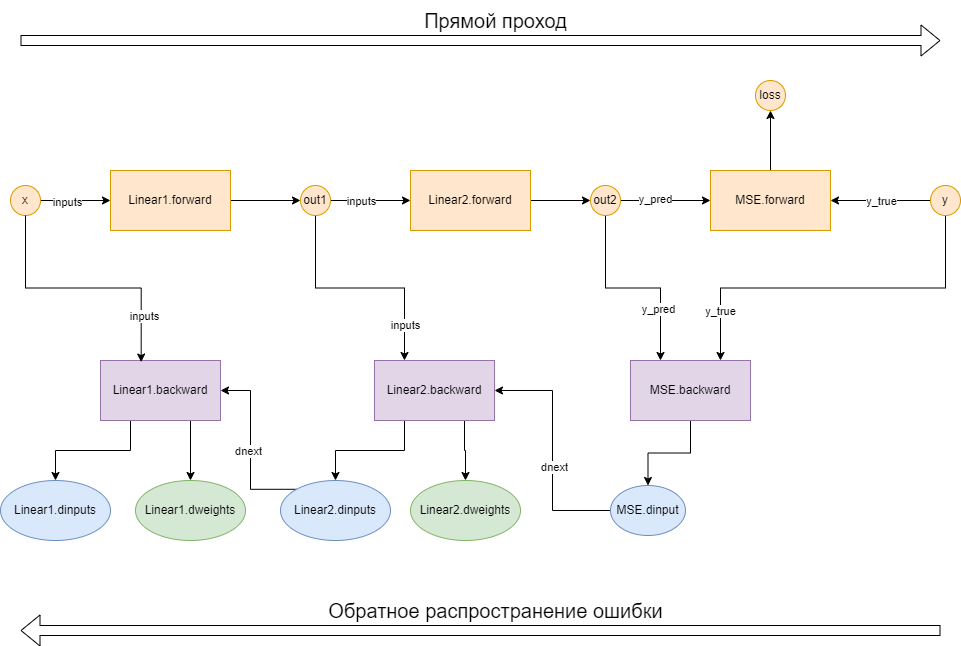

In [ ]:
import torch as th

th.manual_seed(42)
X = th.linspace(-1, 1, 100).view(-1, 1)
y = X.pow(2) + 0.2 * th.rand(X.size()) 

In [22]:
class Linear:
    def __init__(self, n_features: int, n_neurons: int, seed: int | None = None):
        if seed is not None:
            th.manual_seed(seed)
        self.weights = th.randn(n_features + 1, n_neurons) * 0.1

    def add_ones_col(self, inputs):
        ones = th.ones((inputs.shape[0], 1), dtype=inputs.dtype)
        return th.cat((ones, inputs), dim=1)

    def forward(self, inputs):
        self.inputs = inputs
        x_bias = self.add_ones_col(inputs)
        return x_bias @ self.weights

    def backward(self, inputs, dnext):
        x_bias = self.add_ones_col(inputs)
        self.dweights = x_bias.T @ dnext
        self.dinputs = dnext @ self.weights[1:].T


class MSELoss:
    def forward(self, y_pred, y_true):
        return ((y_pred - y_true) ** 2).mean()

    def backward(self, y_pred, y_true):
        self.dinput = 2 * (y_pred - y_true) / y_pred.shape[0]

In [21]:
X = th.linspace(-1, 1, 100).view(-1, 1)
y = X.pow(2) + 0.2 * th.rand(X.size())

In [24]:
linear1 = Linear(1, 10, seed=42)
linear2 = Linear(10, 1, seed=43)
criterion = MSELoss()

lr = 0.1
epochs = 1000
snapshots = {}

for epoch in range(epochs):
    out1 = linear1.forward(X)
    out2 = linear2.forward(out1)

    loss = criterion.forward(out2, y)

    criterion.backward(out2, y)
    linear2.backward(out1, criterion.dinput)
    linear1.backward(X, linear2.dinputs)

    with th.no_grad():
        linear2.weights -= lr * linear2.dweights
        linear1.weights -= lr * linear1.dweights

    if epoch in [0, epochs // 2, epochs - 1]:
        snapshots[epoch] = out2.detach().clone()

    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1}, loss = {loss.item():.6f}")

Epoch 200, loss = 0.093472
Epoch 400, loss = 0.093463
Epoch 600, loss = 0.093463
Epoch 800, loss = 0.093463
Epoch 1000, loss = 0.093463


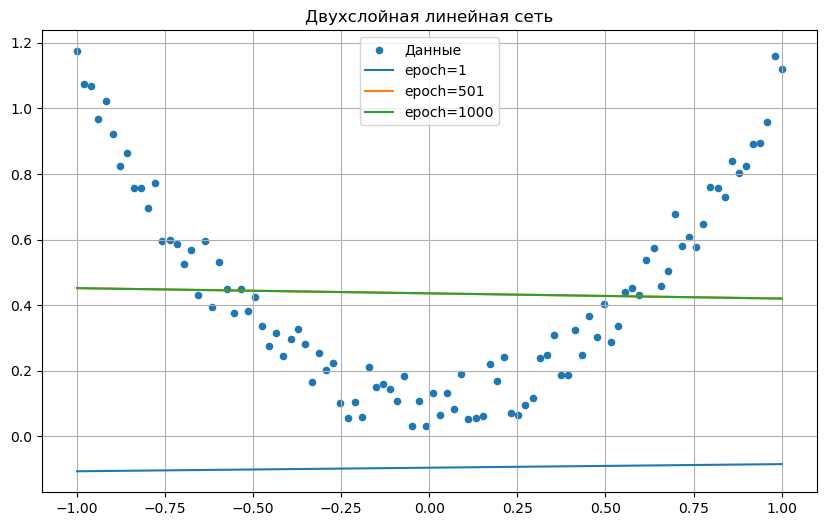

In [25]:
plt.figure(figsize=(10, 6))
plt.scatter(X.numpy(), y.numpy(), label="Данные", s=20)

for epoch, pred in snapshots.items():
    plt.plot(X.numpy(), pred.numpy(), label=f"epoch={epoch+1}")

plt.grid(True)
plt.legend()
plt.title("Двухслойная линейная сеть")
plt.show()

<p class="task" id="6"></p>

6\. Модель из предыдущей задачи является линейной и не способна качественно предсказать искомую зависимость. Для того, чтобы сделать модель нелинейной, в нейронных сетях используются функции активации. Для того, чтобы встроить такую функцию в процесс обратного распространения ошибки, необходимо реализовать соответствующий слой с методами `forward` и `backward`.

$$
f(x) = \max(0, x)
$$

$$
\frac{\partial L}{\partial x} = \frac{\partial L}{\partial f}\frac{\partial f}{\partial x} = \frac{\partial L}{\partial f}
\begin{cases} 
1 & \text{если } x \ge 0 \\
0 & \text{если } x <  0 
\end{cases}
$$

Здесь $L$ - это функция (слой), следующая за ReLU в потоке вычислений.

Реализуйте и обучите модель, состояющую из двух полносвязных слоев, разделенных функцией активации ReLU: 
1. Полносвязный слой с 10 нейронами
2. Активация ReLU
3. Полносвязный слой с 1 нейроном

В процессе обучения сохраняйте промежуточные прогнозы моделей. Визуализируйте облако точек и прогнозы модели в начале, середине и после окончания процесса обучения (не обязательно три, можно взять больше промежуточных вариантов).




- [ ] Проверено на семинаре

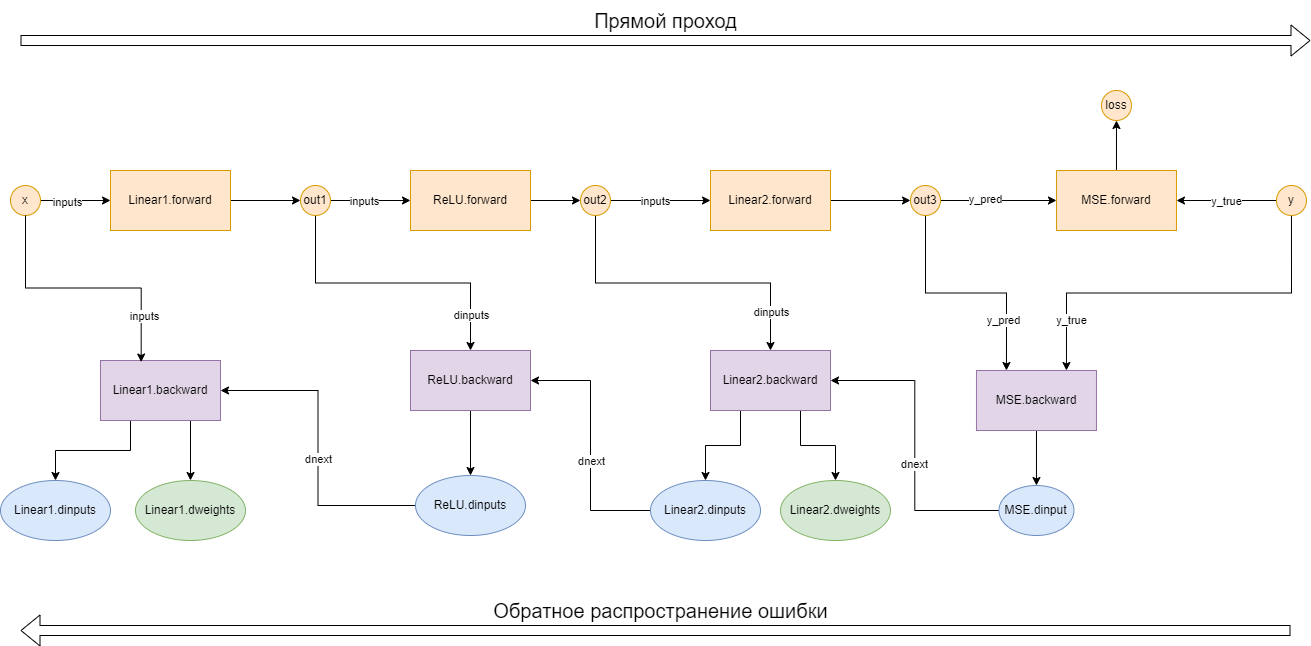

In [26]:
class ReLU:
    def forward(self, inputs):
        return th.maximum(inputs, th.zeros_like(inputs))

    def backward(self, inputs, dvalues):
        mask = (inputs >= 0).float()
        return dvalues * mask

In [30]:
th.manual_seed(42)
X = th.linspace(-1, 1, 100).view(-1, 1)
y = X.pow(2) + 0.2 * th.rand(X.size())

In [31]:
linear1 = Linear(1, 10, seed=42)
relu = ReLU()
linear2 = Linear(10, 1, seed=43)
criterion = MSELoss()

lr = 0.1
epochs = 2000
snapshots = {}

for epoch in range(epochs):
    out1 = linear1.forward(X)
    out2 = relu.forward(out1)
    out3 = linear2.forward(out2)

    loss = criterion.forward(out3, y)

    criterion.backward(out3, y)
    linear2.backward(out2, criterion.dinput)
    drelu = relu.backward(out1, linear2.dinputs)
    linear1.backward(X, drelu)

    with th.no_grad():
        linear2.weights -= lr * linear2.dweights
        linear1.weights -= lr * linear1.dweights

    if epoch in [0, epochs // 4, epochs // 2, epochs - 1]:
        snapshots[epoch] = out3.detach().clone()

    if (epoch + 1) % 400 == 0:
        print(f"Epoch {epoch+1}, loss = {loss.item():.6f}")


Epoch 400, loss = 0.023494
Epoch 800, loss = 0.005720
Epoch 1200, loss = 0.004024
Epoch 1600, loss = 0.003735
Epoch 2000, loss = 0.003686


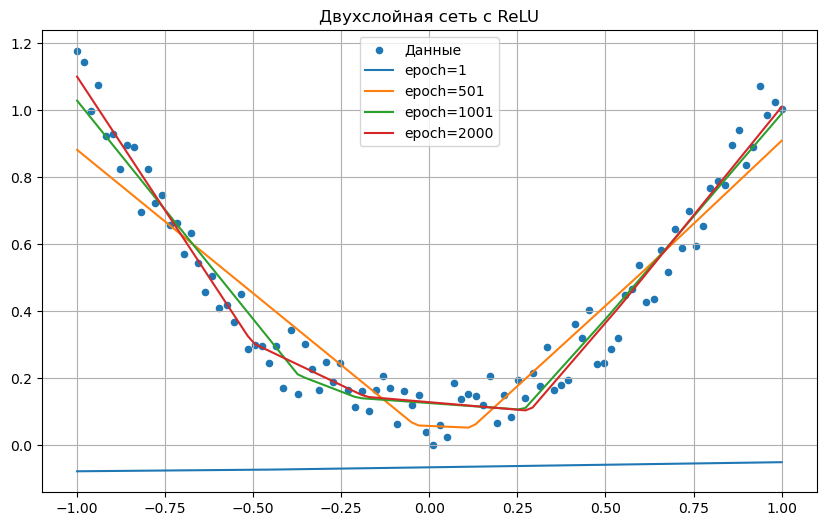

In [32]:
plt.figure(figsize=(10, 6))
plt.scatter(X.numpy(), y.numpy(), label="Данные", s=20)

for epoch, pred in snapshots.items():
    plt.plot(X.numpy(), pred.numpy(), label=f"epoch={epoch+1}")

plt.grid(True)
plt.legend()
plt.title("Двухслойная сеть с ReLU")
plt.show()